## DevOps vs MLOps
- ML/LLM CI/CD add 3 extra gates
    - data validation
    - model evaluation
    - prompte quality chekcks
- Note: in traditional DevOPs mainly 2 gates
    - unit tests, and integration tests
- Skipping any gate will lead to a silent degration in production
- Traditinoal DevOps pipelines are code-centric; ML pipleines mus version **data, models, and prompts **
- Model performance can degrade without code change due to data drift

### DevOps vs MLOps vs LLMOps
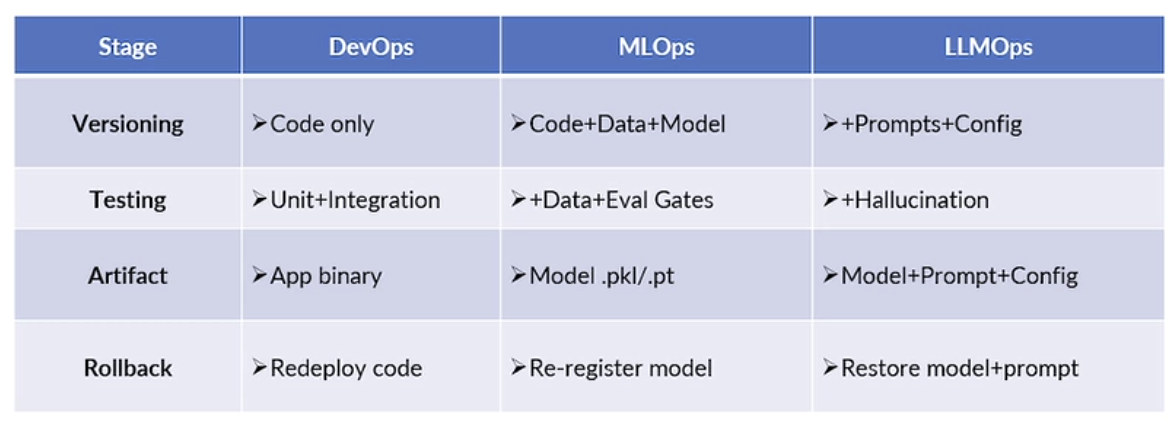

### 3 Silent Failurs when copying DevOps to ML
1. Unit test pass but data schema added a null column
2. Drift not caught - corrupted model trained on new null data
3. Model deployed - accuracy dorps 8% no alert triggered
- Fix: 3 Layer Pyramid: Unit Test -> Data Validation -> Eval Gate

### Why ML CI/CD is different?
- **Data is first class citizen**: model depends on both code and data quality
- **Non-dterministic behaviour**: same code can produce different result with different data
    - sampling
    - randomness
    - evolving data
- **Performance monitoring**: Accuracy/F1 metics are as critical as uptime
- **Gradual degration**: Models silently decaz over time due to data drift

### Real-wold example: Netflix Recommendation CI/CD
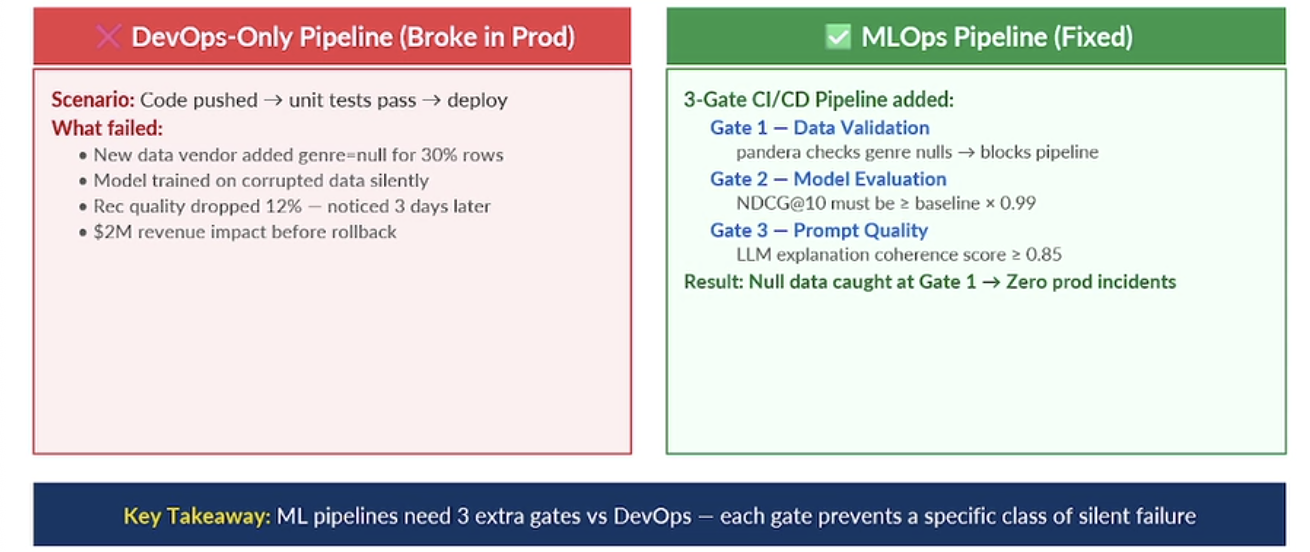

## Automating Build -> Test -> Deploy for ML Pipelines
### Pipeline Autiomation Principles
- Trigger types: push (dev), schedule (daily retrain), PR (eval before merge)
- Parellize gates: unit tests + data schema checks runs in parallel to save time
- Fail fast: data valiation fails -> tsop pipeline, don't waist compute on training
- Artifacts promotion: model only move staging -> Prod when all gates passed

### Daily retrain pipeline
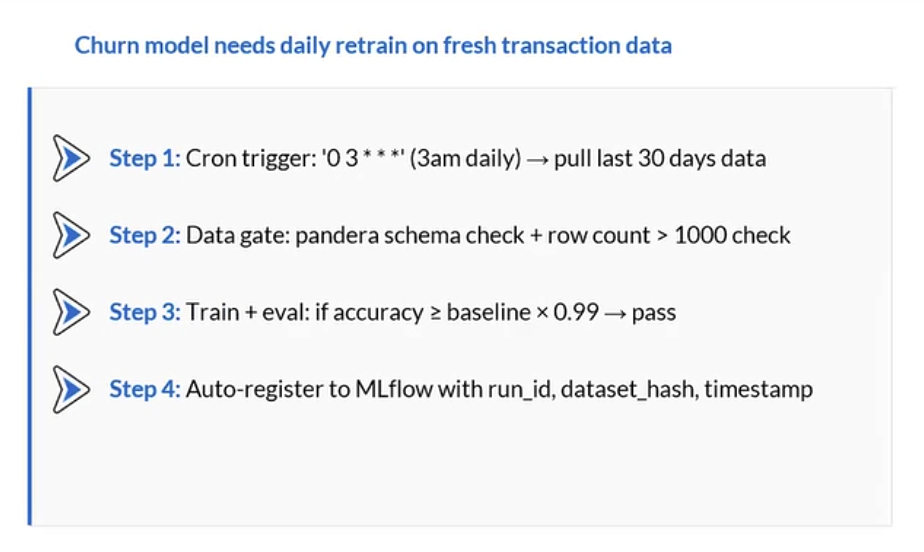

### Pipeline Best Practices
- Notification
    - Slack + email on gate failure with context (matric, threshold)
    - every satage logs results, errors and warnings
- Idempotency
    - Running pipeline with twice with same inputs produce same output
- Resource optimization
    - Use spot instances for training, reseved for inference
- Observability
    - Log all gates decisions, metrices and artifacts versions.

### Setting up scheduled retrain pipeline
- Key components of a GitHub Action schedule pipeline
    - Schedule trigger with crone expression for autiomated runs
    - Maual trigger (workflow_despatch) for on-demand execution
    - Sequential gates: data_pull -> validate -> train -> evaluate -> register
    - Enviroment variables for beaseline metrics and thresholds
    - Notification step using Slack/Teams webhook integration

### Full pipeline example: E-commerse churn model GitHub Action
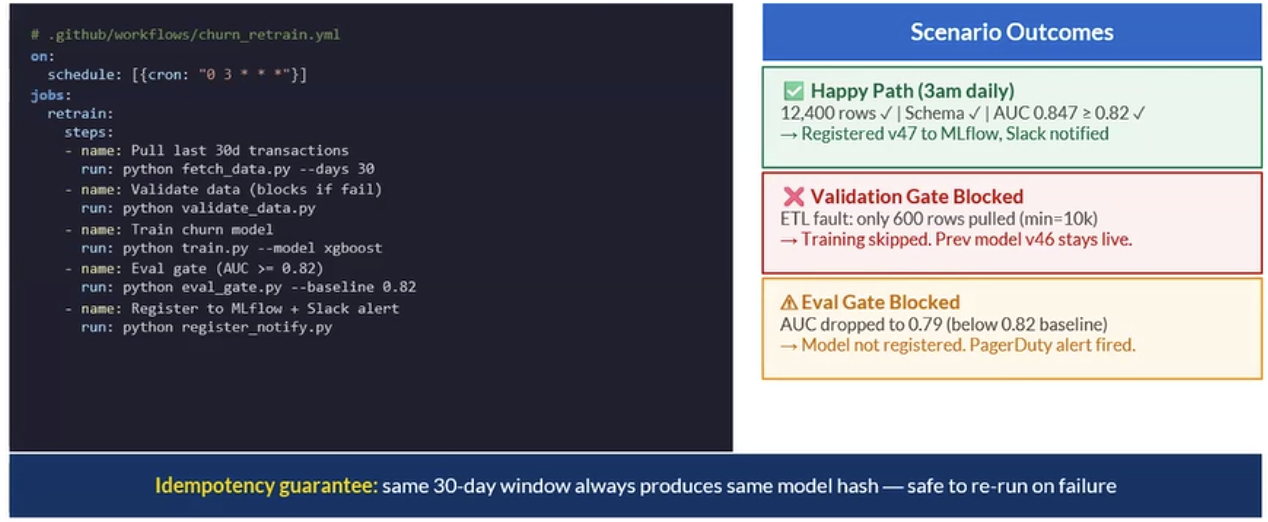


## Integating Model & Data Validation into CI/CD
### Validation Types and Tools
- 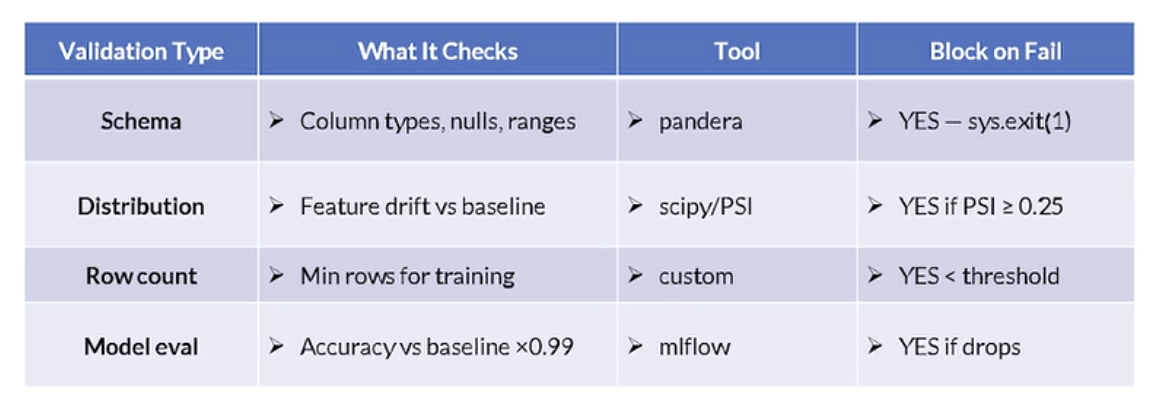

### Validation Requirements
- <i>Every valiaiton must produce structured logs and exit code 1 on fail </i>
- **Schema check**: pandera.validate(df) -> logs col_nmaes + error type
- **Row count**: assert len(df) >= MIN_ROWS else sys.exit(1)
- **Null check**: assert df.isnull().sum.max() == 0
- **Logging**: Log to stdout JSON for GitHub Action log capture

### validate_data.py 
- Define schema with pandera DataFrameSchema for column types and constraints
- Check minimum row count requirement before training
- Validate schema and cach SchmaError exceptions
- Collect all erros into structured JSON format
- Print error to stdout and call sys.exit(1) to block pipeline
- On success, print pass status with row count

### Key Validation Principles
- **Fall loudly**: Never silently skip validation failure
- **Structured logging**: Json output emabels automatic alerting and dashbords
- **Verison control**: Schema definitions live in git alongside code
- **Progressive validation**: Run cheap checks first, expensive checklist last

### Worked Example: validate_data.py for Churn Model
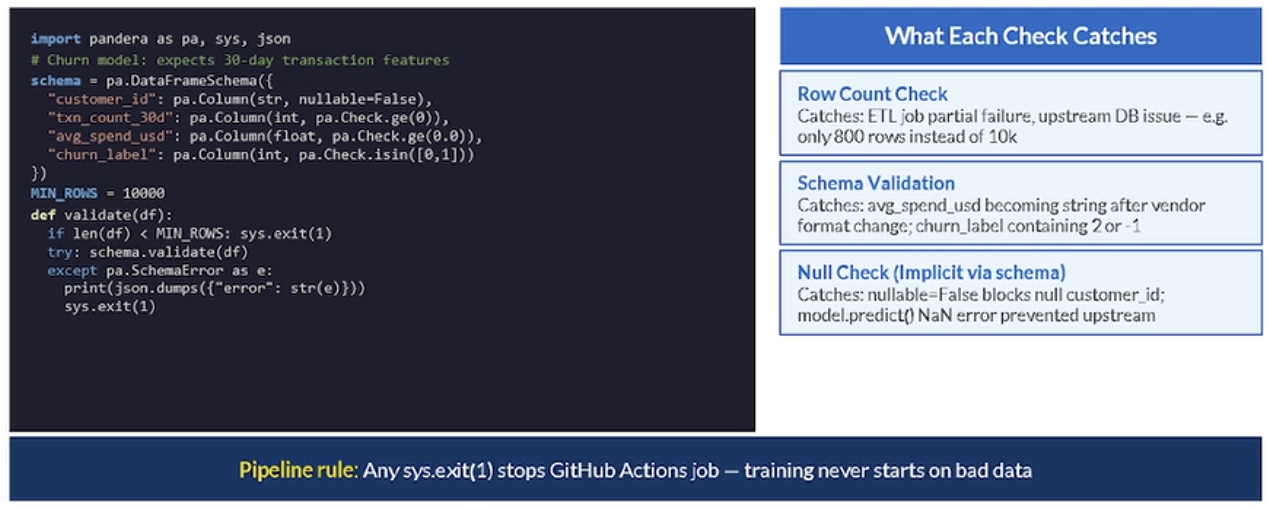

## Readings
- [Continuous Integration and Continuous Deployment (CI/CD) in MLOps](https://www.geeksforgeeks.org/machine-learning/continuous-integration-and-continuous-deployment-ci-cd-in-mlops/)
- [AI ML Ops: Building a Seamless CI/CD Pipeline for ML Models](http://bigsteptech.com/blog/ai-and-ml-ops-building-a-seamless-ci-cd-pipeline-for-ml-models)
- [CI/CD Best Practices for Accelerating Multi-Stage MLOps Deployments](https://www.mlopscrew.com/blog/cicd-best-practices-for-accelerating-mlops-deployment)


## Model Versioning & Release Mangement
- sematic versioning for **Models**, **Prompts**, and **Datasets**

### Versioning strategy
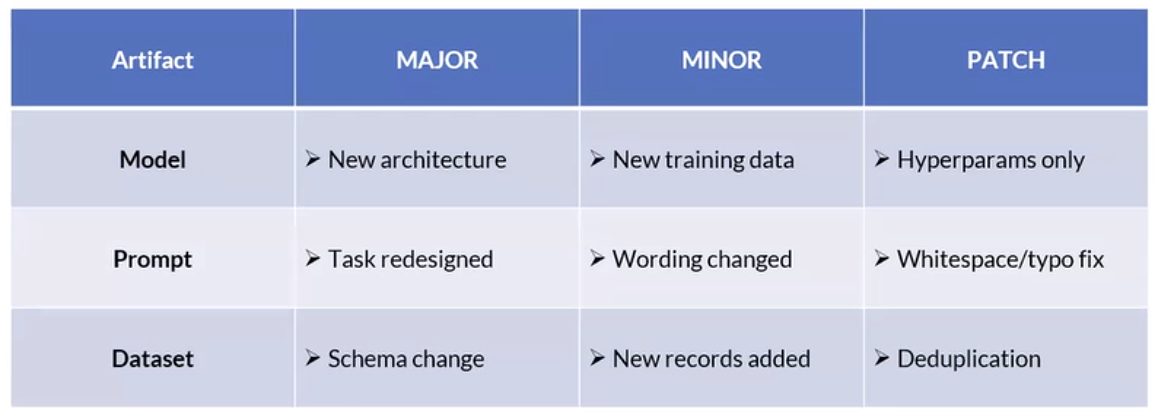
- each mdoel, prompt, and dataset is verioned
- each evolved indipendently
- every chanage has a meaning

### Deployment Tuple Rule
- Always deploy as a tuple: (Model-v2.1.0, prompt-v1.3.2, dataset-v5.0.0)
- Log this tuple per inference to enable exact reproduction of any past result
- 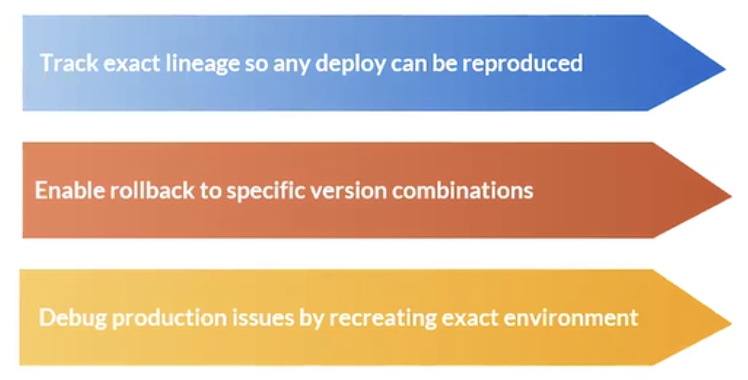

- in data science project, the result is not depends only alone the code, it depends on data, code, and model.
- we can go back to the past and find 
    - model
    - data
    - prompt
- given the result

### MLflow Registry: Training Run -> Staging in 5 Steps
- Start run - log params: dataset_version, prompt_verion
- Log metrics: Accuracy = 0.8891, f1 = 0.8847
- Register: mlflow.sklearn.log_model(registered_model_name='clf')
- Tag: semantic_version='v2.1.0', commit_sha='abc1234'
- Transition: client.transition_model_verion_stage -> Staging

### Key Versioning Principles
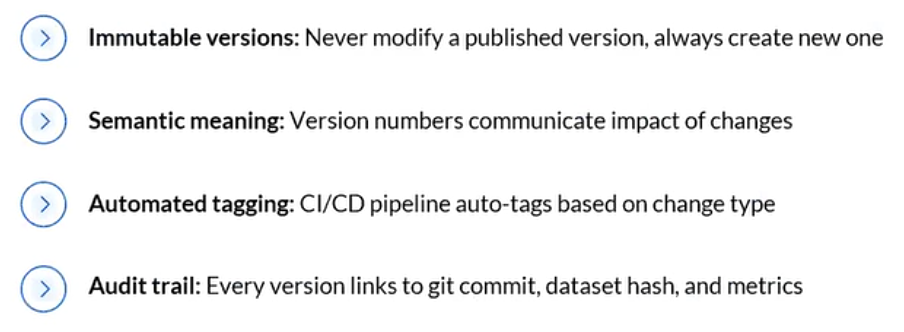

### Implementation Example
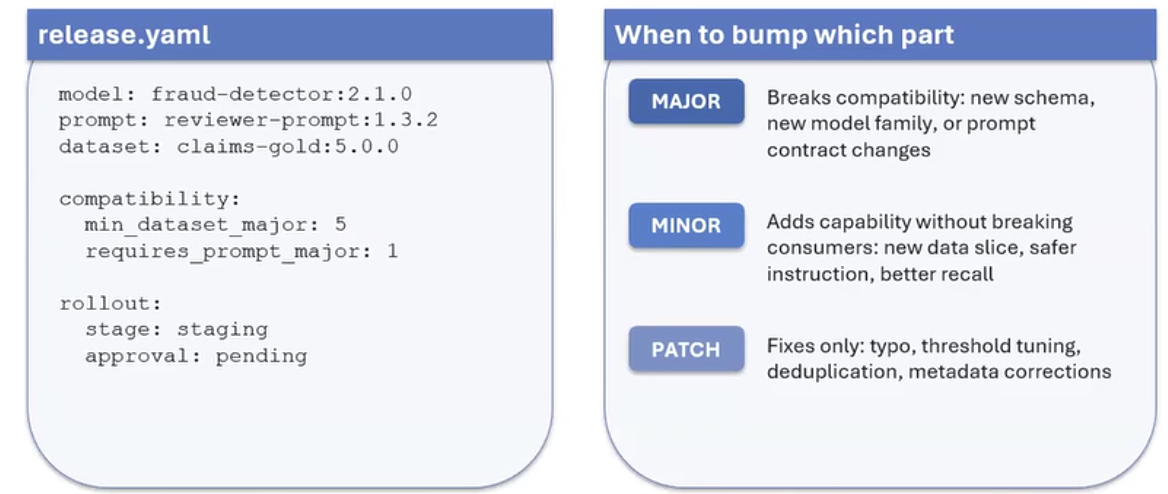
- <i>Keep one deplozable release manifest per serving change so everz prediciton can be traced to an exact model+prompt+dataset tuple</i>

- release.yaml file defines the serivig package explicitly
- the compatability prevents the unsupported version combinations reaching production

## Model Registers: MLflow, W&B, and Custom Systems
- stroe the trained model, version it, track the meta data, and control how the model is moved from staging to production

- Model Registry
    - MLFlow
    - Weights and Biases
    - Custom Systems

### Registry Comparison
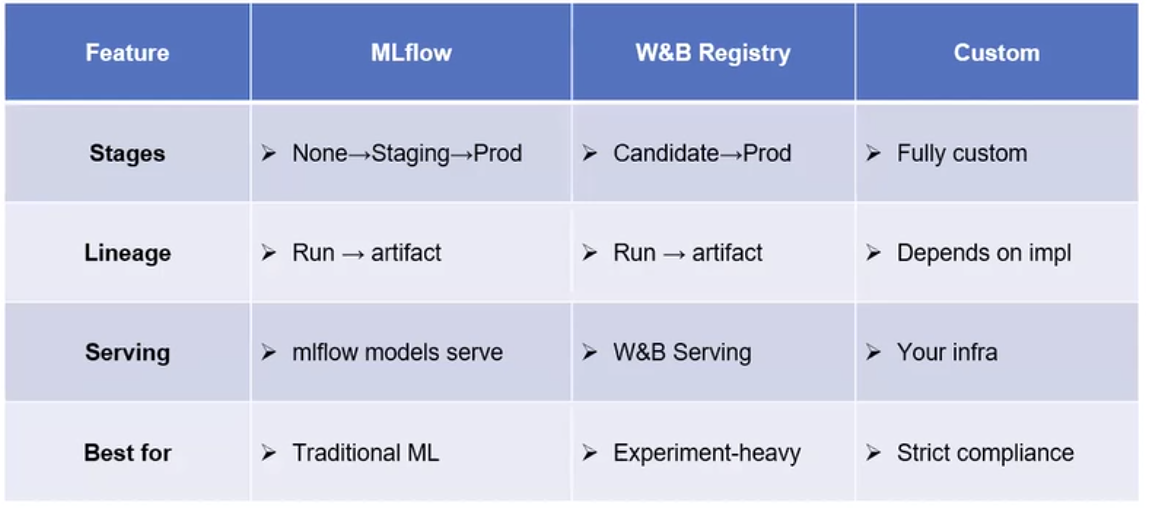

- MLflow
    - widely used opensource registry
    - used when, experiment, tracking and model life cycle management
- Weights and Biases (W&B) Registry
    - when team uses this for their expirimentation

